Dataset: 69 productos | 44 semanas
Exógena creada: total semanal
Ventanas creadas: X=(2622, 12) | y=(2622,)
Split: Train=(2097, 12) | Test=(525, 12)

Entrenando modelo...
Epoch   1 | Train Loss: 65.105 | Test Loss: 521.987
Epoch  50 | Train Loss: 2.665 | Test Loss: 2.348
Epoch 100 | Train Loss: 1.567 | Test Loss: 1.503
Epoch 150 | Train Loss: 1.310 | Test Loss: 1.638
Epoch 200 | Train Loss: 1.220 | Test Loss: 1.593
Epoch 250 | Train Loss: 1.461 | Test Loss: 1.709
Epoch 300 | Train Loss: 1.145 | Test Loss: 1.567
Epoch 350 | Train Loss: 1.131 | Test Loss: 1.566
Epoch 400 | Train Loss: 1.120 | Test Loss: 1.557

Top 20 predicciones:
                         Producto  Prediccion_Siguiente_Semana
  Leche alpura deslactosada Ligth                           25
            Leche alpura regular                            14
              Margarina Yurecuaro                            8
             Mantequilla Eugenia                             7
      Vaso enserado Tornado 16 0z               

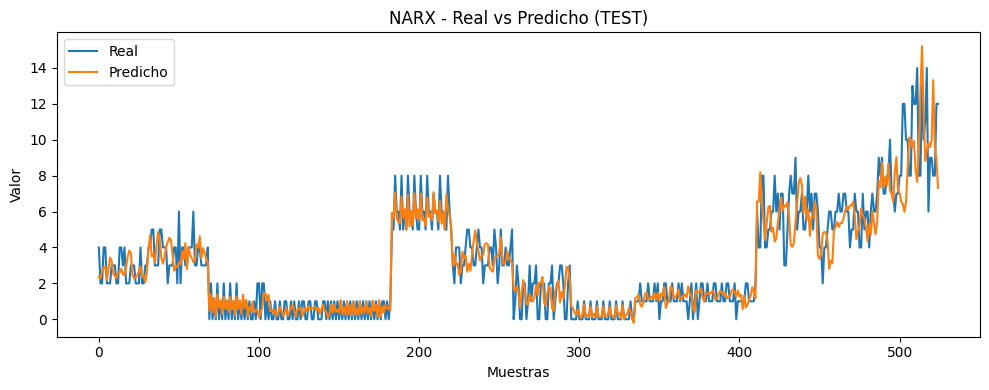

In [4]:
# ============================================================
# MODELO NARX (Nonlinear AutoRegressive with eXogenous inputs)
# Predice ventas de la siguiente semana por producto usando:
#  - Historial del producto (6 semanas)
#  - Historial del total semanal (6 semanas)
#
# y(t) = f( y(t-6..t-1), x(t-6..t-1) )
# ============================================================

# -----------------------------
# IMPORTAR LIBRERÍAS
# -----------------------------
import pandas as pd              # Manejo de tablas (CSV)
import numpy as np               # Operaciones numéricas
import torch                     # PyTorch
from torch import nn             # Capas neuronales
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# -----------------------------
# 1) CONFIGURACIÓN GENERAL
# -----------------------------
CSV_PATH  = "Panquel_Dataset_V2.csv"  # Archivo de datos
LAGS      = 6                         # Semanas pasadas usadas
TEST_SIZE = 0.2                       # 20% para prueba
EPOCHS    = 400                       # Iteraciones de entrenamiento
LR        = 0.01                      # Velocidad de aprendizaje
SEED      = 42                        # Semilla aleatoria

# Fijar semillas → resultados reproducibles
np.random.seed(SEED)
torch.manual_seed(SEED)

# -----------------------------
# 2) CARGA DEL DATASET
# -----------------------------
df = pd.read_csv(CSV_PATH)

name_col = "Unnamed: 0"                 # Columna con nombres
products = df[name_col].astype(str).values

# Quitamos columna de nombres y dejamos solo números
data = (
    df.drop(columns=[name_col])
      .apply(pd.to_numeric, errors="coerce")
      .fillna(0.0)
      .values.astype(np.float32)
)

n_products, n_weeks = data.shape
print(f"Dataset: {n_products} productos | {n_weeks} semanas")

# -----------------------------
# 3) CREAR VARIABLE EXÓGENA
# -----------------------------
# Total semanal = suma de todos los productos por semana
# Representa el nivel global de demanda
exo_total = data.sum(axis=0).astype(np.float32)

print("Exógena creada: total semanal")

# -----------------------------
# 4) CREAR VENTANAS NARX
# -----------------------------
# Para cada producto y semana:
#   Entrada = [6 semanas del producto + 6 semanas del total]
#   Salida  = valor real de esa semana

def make_windows_narx(data_matrix, exo_series, lags=6):
    X_list, y_list = [], []
    n_products, n_weeks = data_matrix.shape

    for p in range(n_products):
        serie_producto = data_matrix[p]

        for t in range(lags, n_weeks):
            # Últimas 6 semanas del producto
            y_lags = serie_producto[t-lags:t]

            # Últimas 6 semanas del total semanal
            x_lags = exo_series[t-lags:t]

            # Concatenar ambas
            X_list.append(np.concatenate([y_lags, x_lags]))
            y_list.append(serie_producto[t])

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

X, y = make_windows_narx(data, exo_total, LAGS)

print(f"Ventanas creadas: X={X.shape} | y={y.shape}")

# -----------------------------
# 5) TRAIN / TEST (SIN MEZCLAR)
# -----------------------------
# No usamos shuffle porque son series temporales
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, shuffle=False
)

# Convertimos a tensores
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train).unsqueeze(1)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test).unsqueeze(1)

print(f"Split: Train={X_train.shape} | Test={X_test.shape}")

# -----------------------------
# 6) DEFINICIÓN DEL MODELO
# -----------------------------
# Red neuronal densa (MLP)
# Entrada: 12 valores (6 y + 6 x)
# Salida: 1 valor (predicción)

class NeuralNARX(nn.Module):
    def __init__(self, input_size):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = NeuralNARX(input_size=2 * LAGS)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

# -----------------------------
# 7) ENTRENAMIENTO
# -----------------------------
print("\nEntrenando modelo...")

for epoch in range(1, EPOCHS + 1):
    model.train()

    optimizer.zero_grad()
    pred = model(X_train_t)
    loss = loss_fn(pred, y_train_t)

    loss.backward()
    optimizer.step()

    if epoch == 1 or epoch % 50 == 0:
        model.eval()
        with torch.no_grad():
            pred_test = model(X_test_t)
            loss_test = loss_fn(pred_test, y_test_t)

        print(f"Epoch {epoch:3d} | Train Loss: {loss.item():.3f} | Test Loss: {loss_test.item():.3f}")

# -----------------------------
# 8) PREDICCIÓN PRÓXIMA SEMANA
# -----------------------------
# Para cada producto:
#   Tomamos sus últimas 6 semanas
#   Tomamos las últimas 6 semanas del total
#   Predecimos un paso adelante

model.eval()
pred_next = []

last_x = exo_total[-LAGS:]

with torch.no_grad():
    for p in range(n_products):
        last_y = data[p, -LAGS:]
        x_in = np.concatenate([last_y, last_x])
        pred = model(torch.tensor(x_in).unsqueeze(0)).item()
        pred_next.append(pred)

pred_next = np.array(pred_next)

# Redondear y evitar negativos
pred_next_round = np.clip(np.rint(pred_next), 0, None).astype(int)

results = pd.DataFrame({
    "Producto": products,
    "Prediccion_Siguiente_Semana": pred_next_round
}).sort_values("Prediccion_Siguiente_Semana", ascending=False)

print("\nTop 20 predicciones:")
print(results.head(20).to_string(index=False))
print("\nTOTAL próxima semana:", int(pred_next_round.sum()))

# -----------------------------
# 9) MÉTRICAS EN TEST
# -----------------------------
with torch.no_grad():
    y_pred_test = model(X_test_t).squeeze().numpy()

y_true_test = y_test

mae = mean_absolute_error(y_true_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))

mask = (y_true_test != 0)
mape = (
    np.mean(np.abs((y_true_test[mask] - y_pred_test[mask]) / y_true_test[mask])) * 100
    if np.any(mask) else np.nan
)

print("\nMÉTRICAS")
print(f"MAE : {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%" if not np.isnan(mape) else "MAPE: N/A")

# -----------------------------
# 10) GRÁFICA REAL vs PREDICHO
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(y_true_test, label="Real")
plt.plot(y_pred_test, label="Predicho")
plt.title("NARX - Real vs Predicho (TEST)")
plt.xlabel("Muestras")
plt.ylabel("Valor")
plt.legend()
plt.tight_layout()
plt.show()
